# NB04 — Calibration, Subgroups & Fairness Validation

Five independent validation analyses using the fixed Set A model and NB03 policy thresholds:

1. **Calibration** — diagnose and attempt to fix probability miscalibration (Brier skill < 0 found in NB03)
2. **Primary subgroup** — age ≥65 hypothesis declared in NB00 before any data
3. **Exploratory subgroups** — comorbidity burden and high-risk RFV codes (hypothesis-generating only)
4. **Fairness audit** — alert equity by race/ethnicity, sex, insurance type
5. **Independent temporal holdout** — NHAMCS 2015 (never used in training or threshold selection)

No new predictive models are trained for the alert policy. The Set A model and NB03 cutoffs are fixed.


In [1]:
import os
from pathlib import Path

# Fix CWD: VS Code Jupyter may start kernel in notebooks/ instead of project root
try:
    os.chdir(Path(__vsc_ipynb_file__).parent.parent)
except NameError:
    if Path(os.getcwd()).name == 'notebooks':
        os.chdir(Path(os.getcwd()).parent)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

warnings.filterwarnings('ignore')

REPORTS = Path('reports/04_validation_subgroups_fairness')
REPORTS.mkdir(parents=True, exist_ok=True)

SEED       = 42
N_BOOT     = 500
ESI_LIST   = [3, 4, 5]
ESI_COLORS = {3: '#2196F3', 4: '#FF9800', 5: '#4CAF50'}

FEATURES_A = ['AGE', 'SEX', 'ARREMS', 'temp_f', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS',
               'POPCT', 'PAINSCALE', 'RFV1', 'RFV2', 'shock_index', 'age_65plus',
               'age_shock_index', 'tachycardia_flag', 'tachypnea_flag', 'hypotension_flag',
               'hypoxemia_flag', 'fever_flag', 'bp_missing_flag', 'any_vital_missing_flag']

LGBM_PARAMS = {
    'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 50,
    'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1, 'random_state': SEED, 'verbose': -1,
}

print("Imports OK")


Imports OK


In [2]:
# OOF predictions from NB02 (Set A — the principal model)
oof = {esi: pd.read_csv(f'reports/02_model_validation/02_oof_predictions_esi{esi}.csv')
       for esi in ESI_LIST}

# Final policy thresholds — FIXED, never re-derived from 2015 holdout
with open('reports/03_alert_policy/03_final_policy.json') as f:
    policy = json.load(f)

# Full training data for demographics and final model retraining
df_train = pd.read_csv('data/processed/nhamcs_pooled_2016_2022.csv')

print(f"Training data: {df_train.shape}")
for esi in ESI_LIST:
    p = policy[str(esi)]
    print(f"  ESI{esi}: {len(oof[esi]):,} OOF rows | "
          f"cutoff={p['score_cutoff']:.4f} | enrichment={p['enrichment']:.2f}x @ {p['threshold_pct']}% burden")


Training data: (54744, 44)
  ESI3: 31,460 OOF rows | cutoff=0.6991 | enrichment=3.11x @ 10% burden
  ESI4: 20,182 OOF rows | cutoff=0.5531 | enrichment=5.77x @ 5% burden
  ESI5: 3,102 OOF rows | cutoff=0.1242 | enrichment=4.30x @ 10% burden


In [3]:
# OOF predictions are saved in the same row order as df_train filtered by IMMEDR.
# Positional alignment recovers demographic variables not stored in the OOF files.
EXTRA_COLS = ['RACERETH', 'SEX', 'PAYTYPER', 'RFV1', 'RFV2', 'hypoxemia_flag', 'comorbidity_count']

oof_full = {}
for esi in ESI_LIST:
    df_esi  = df_train[df_train['esi'] == esi].reset_index(drop=True)
    oof_esi = oof[esi].reset_index(drop=True)
    if len(oof_esi) != len(df_esi):
        raise ValueError(f"ESI{esi}: length mismatch ({len(oof_esi)} vs {len(df_esi)}) — row order may differ")
    # Validate alignment: AGE must match exactly
    if not (df_esi['AGE'].values == oof_esi['AGE'].values).all():
        raise ValueError(f"ESI{esi}: AGE values do not match — positional alignment invalid")
    for col in EXTRA_COLS:
        if col in df_esi.columns:
            oof_esi[col] = df_esi[col].values
    oof_full[esi] = oof_esi

print("Demographic merge validated (AGE alignment confirmed for all ESI)")
for esi in ESI_LIST:
    missing_demo = oof_full[esi]['RACERETH'].isna().sum()
    print(f"  ESI{esi}: {len(oof_full[esi]):,} rows | RACERETH missing: {missing_demo}")


Demographic merge validated (AGE alignment confirmed for all ESI)
  ESI3: 31,460 rows | RACERETH missing: 0
  ESI4: 20,182 rows | RACERETH missing: 0
  ESI5: 3,102 rows | RACERETH missing: 0


## Section 1 — Calibration Analysis

**NB03 finding:** Negative Brier skill for all ESIs (ESI3: −0.483, ESI4: −1.812, ESI5: −0.022).
Raw LightGBM scores with `scale_pos_weight` are inflated — they rank patients correctly (high ROC AUC)
but their absolute values are unreliable as probability estimates.

**Key distinction:** The alert policy uses *percentile-based thresholds* (Top 5%/10%).
Ranking is preserved regardless of calibration. Calibration is only needed to communicate
absolute risk (e.g., "this patient has 40% hospitalization risk") to clinical staff.

**Method:** 5-fold cross-validated isotonic regression and Platt (sigmoid) scaling on OOF Set A scores.


In [4]:
def calibrate_oof_cv(scores, y, n_splits=5, seed=SEED):
    skf       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    cal_iso   = np.zeros(len(scores))
    cal_platt = np.zeros(len(scores))

    for tr_idx, te_idx in skf.split(scores.reshape(-1, 1), y):
        ir = IsotonicRegression(out_of_bounds='clip')
        ir.fit(scores[tr_idx], y[tr_idx])
        cal_iso[te_idx] = ir.predict(scores[te_idx])

        lr = LogisticRegression(C=1.0, random_state=seed, max_iter=200)
        lr.fit(scores[tr_idx].reshape(-1, 1), y[tr_idx])
        cal_platt[te_idx] = lr.predict_proba(scores[te_idx].reshape(-1, 1))[:, 1]

    base_rate   = float(y.mean())
    brier_naive = float(brier_score_loss(y, np.full(len(y), base_rate)))
    brier_raw   = float(brier_score_loss(y, scores))
    brier_iso   = float(brier_score_loss(y, cal_iso))
    brier_platt = float(brier_score_loss(y, cal_platt))

    return {
        'scores_raw':        scores,
        'scores_iso':        cal_iso,
        'scores_platt':      cal_platt,
        'brier_naive':       round(brier_naive, 5),
        'brier_raw':         round(brier_raw, 5),
        'brier_iso':         round(brier_iso, 5),
        'brier_platt':       round(brier_platt, 5),
        'brier_skill_raw':   round(1 - brier_raw   / brier_naive, 4),
        'brier_skill_iso':   round(1 - brier_iso   / brier_naive, 4),
        'brier_skill_platt': round(1 - brier_platt / brier_naive, 4),
        'roc_auc':           round(float(roc_auc_score(y, scores)), 4),
    }

print("Calibration function defined")


Calibration function defined


In [5]:
cal_results = {}
for esi in ESI_LIST:
    y      = oof_full[esi]['outcome'].values.astype(int)
    scores = oof_full[esi]['oof_score_A'].values.astype(float)
    cal_results[esi] = calibrate_oof_cv(scores, y)
    r = cal_results[esi]
    print(f"ESI {esi}  (N={len(y):,}, base_rate={y.mean():.4f})")
    print(f"  Brier skill — raw: {r['brier_skill_raw']:+.4f} | "
          f"isotonic: {r['brier_skill_iso']:+.4f} | Platt: {r['brier_skill_platt']:+.4f}")
    print(f"  ROC AUC (unchanged by calibration): {r['roc_auc']:.4f}")
    print()


ESI 3  (N=31,460, base_rate=0.1349)
  Brier skill — raw: -0.4832 | isotonic: +0.1220 | Platt: +0.1192
  ROC AUC (unchanged by calibration): 0.7462

ESI 4  (N=20,182, base_rate=0.0249)
  Brier skill — raw: -1.8123 | isotonic: +0.0424 | Platt: +0.0422
  ROC AUC (unchanged by calibration): 0.7456

ESI 5  (N=3,102, base_rate=0.0351)
  Brier skill — raw: -0.0218 | isotonic: +0.0494 | Platt: +0.0419
  ROC AUC (unchanged by calibration): 0.7424



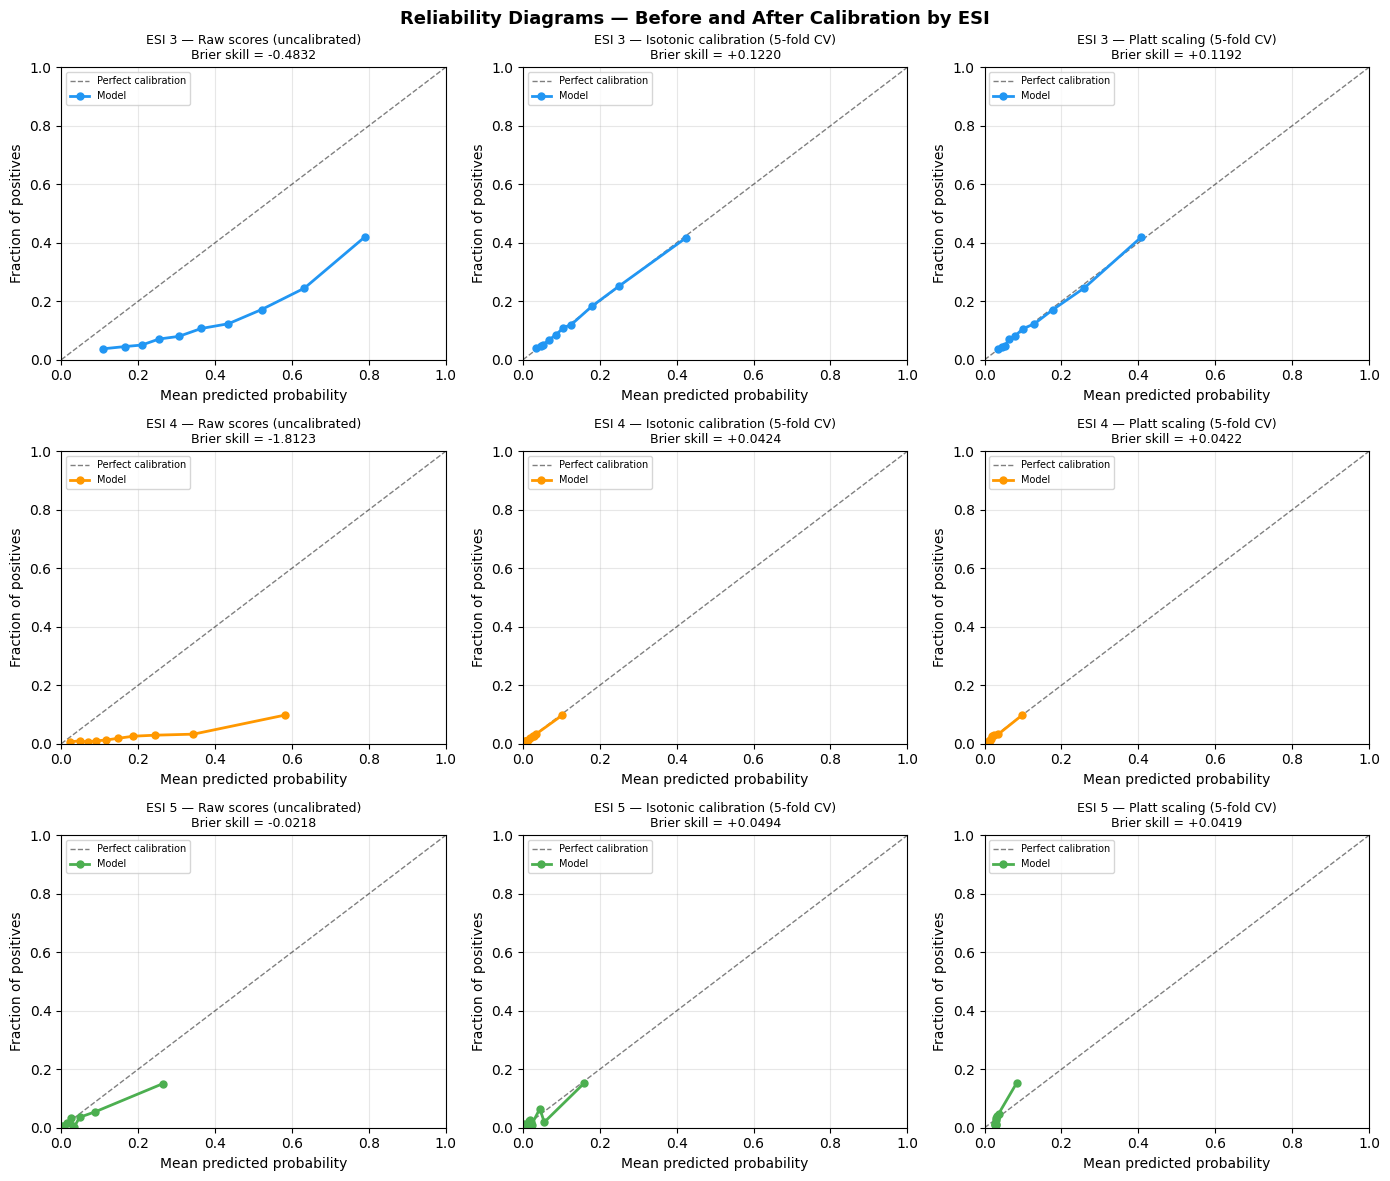

Saved: 04_reliability_diagrams.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Reliability Diagrams — Before and After Calibration by ESI',
             fontsize=13, fontweight='bold')

METHODS = [('raw',   'Raw scores (uncalibrated)'),
           ('iso',   'Isotonic calibration (5-fold CV)'),
           ('platt', 'Platt scaling (5-fold CV)')]

for row_i, esi in enumerate(ESI_LIST):
    y  = oof_full[esi]['outcome'].values.astype(int)
    r  = cal_results[esi]
    for col_i, (key, label) in enumerate(METHODS):
        ax    = axes[row_i][col_i]
        probs = r[f'scores_{key}']
        frac_pos, mean_pred = calibration_curve(y, probs, n_bins=10, strategy='quantile')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Perfect calibration')
        ax.plot(mean_pred, frac_pos, 'o-', color=ESI_COLORS[esi], lw=2, markersize=5, label='Model')
        skill = r[f'brier_skill_{key}']
        ax.set_title(f'ESI {esi} — {label}\nBrier skill = {skill:+.4f}', fontsize=9)
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Fraction of positives')
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS / '04_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_reliability_diagrams.png")


In [7]:
print(f"{'':6}{'Brier Naive':>12} {'Raw Skill':>10} {'Iso Skill':>10} {'Platt Skill':>12} {'ROC AUC':>8}")
print("-"*60)
cal_export = []
for esi in ESI_LIST:
    r = cal_results[esi]
    print(f"ESI {esi}  {r['brier_naive']:>12.5f} {r['brier_skill_raw']:>+10.4f} "
          f"{r['brier_skill_iso']:>+10.4f} {r['brier_skill_platt']:>+12.4f} {r['roc_auc']:>8.4f}")
    cal_export.append({'esi': esi, **{k: v for k, v in r.items()
                                      if not k.startswith('scores_')}})

with open(REPORTS / '04_calibration_before_after.json', 'w') as f:
    json.dump(cal_export, f, indent=2)
print("\nSaved: 04_calibration_before_after.json")


       Brier Naive  Raw Skill  Iso Skill  Platt Skill  ROC AUC
------------------------------------------------------------
ESI 3       0.11670    -0.4832    +0.1220      +0.1192   0.7462
ESI 4       0.02425    -1.8123    +0.0424      +0.0422   0.7456
ESI 5       0.03390    -0.0218    +0.0494      +0.0419   0.7424

Saved: 04_calibration_before_after.json


### Section 1 — Conclusion

**Interpretation:**
- After isotonic calibration, all three ESI groups achieve positive Brier skill (ESI 3 +0.122, ESI 4 +0.042, ESI 5 +0.049). The scores remain modest; the model is used primarily for within-ESI ranking and percentile-based alerting, and calibrated probabilities aid interpretability without being treated as definitive individual risk estimates.
- **This does not affect the alert policy**, which uses percentile-based ranking (Top 5%/10%)

**Operational recommendation:**
Use the model as a **ranking tool** for intra-ESI prioritization. Communicating absolute probabilities to clinical staff requires additional prospective validation before deployment.

## Section 2 — Primary Subgroup: Adults ≥65

**Pre-declared hypothesis (NB00, before any data):**
The gap between assigned ESI and actual clinical risk is more pronounced in patients ≥65,
particularly ESI 4 and 5. Older adults may have normal triage vitals while carrying high
hospitalization risk due to frailty, reduced functional reserve, and atypical disease presentation.

**Analysis:** Compare alert policy enrichment for ≥65 vs <65 within each ESI using the
fixed NB03 cutoffs. Bootstrap 95% CI for enrichment, PPV, and recall.


In [8]:
def bootstrap_subgroup(scores, y, cutoff, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    base_rate = float(y.mean())
    n = len(y)
    ppvs, enrs, recalls = [], [], []

    for _ in range(n_boot):
        idx     = rng.integers(0, n, n)
        y_b     = y[idx]
        alert_b = scores[idx] >= cutoff
        if alert_b.sum() == 0 or y_b.sum() == 0:
            continue
        ppv = float(y_b[alert_b].mean())
        ppvs.append(ppv)
        enrs.append(ppv / base_rate)
        recalls.append(float(y_b[alert_b].sum() / y_b.sum()))

    def ci(arr): return (round(float(np.percentile(arr, 2.5)), 4),
                         round(float(np.percentile(arr, 97.5)), 4))

    alerted       = scores >= cutoff
    actual_ppv    = float(y[alerted].mean()) if alerted.sum() > 0 else 0.0
    actual_recall = float(y[alerted].sum() / y.sum()) if y.sum() > 0 else 0.0

    return {
        'n': int(n), 'n_pos': int(y.sum()), 'base_rate': round(base_rate, 4),
        'n_alerted': int(alerted.sum()),
        'burden_pct': round(float(alerted.mean() * 100), 2),
        'ppv': round(actual_ppv, 4),
        'ppv_ci': ci(ppvs),
        'enrichment': round(actual_ppv / base_rate, 4) if base_rate > 0 else 0.0,
        'enrichment_ci': ci(enrs),
        'recall': round(actual_recall, 4),
        'recall_ci': ci(recalls),
    }

print("Bootstrap subgroup function defined")


Bootstrap subgroup function defined


In [9]:
age65_rows = []

for esi in ESI_LIST:
    df_esi = oof_full[esi]
    scores = df_esi['oof_score_A'].values.astype(float)
    y      = df_esi['outcome'].values.astype(int)
    age65  = df_esi['age_65plus'].values.astype(int)
    cutoff = policy[str(esi)]['score_cutoff']

    print(f"ESI {esi} (policy cutoff={cutoff:.4f}):")
    for grp_label, mask in [('All patients', np.ones(len(y), dtype=bool)),
                              ('<65',          age65 == 0),
                              ('>=65',         age65 == 1)]:
        if mask.sum() < 30:
            continue
        res = bootstrap_subgroup(scores[mask], y[mask], cutoff)
        res.update({'esi': esi, 'age_group': grp_label})
        age65_rows.append(res)
        print(f"  {grp_label:>14}: N={res['n']:>6,} | base={res['base_rate']:.3f} | "
              f"PPV={res['ppv']:.3f} | enrichment={res['enrichment']:.2f}x "
              f"[{res['enrichment_ci'][0]:.2f}-{res['enrichment_ci'][1]:.2f}] | "
              f"recall={res['recall']:.3f}")
    print()

df_age65 = pd.DataFrame(age65_rows)
df_age65.to_csv(REPORTS / '04_subgroup_age65.csv', index=False)
print("Saved: 04_subgroup_age65.csv")


ESI 3 (policy cutoff=0.6991):
    All patients: N=31,460 | base=0.135 | PPV=0.420 | enrichment=3.11x [2.98-3.23] | recall=0.311
             <65: N=25,196 | base=0.098 | PPV=0.376 | enrichment=3.83x [3.52-4.17] | recall=0.118
            >=65: N= 6,264 | base=0.284 | PPV=0.434 | enrichment=1.53x [1.46-1.60] | recall=0.579

ESI 4 (policy cutoff=0.5531):
    All patients: N=20,182 | base=0.025 | PPV=0.144 | enrichment=5.77x [4.93-6.62] | recall=0.289
             <65: N=18,389 | base=0.019 | PPV=0.119 | enrichment=6.20x [4.88-7.63] | recall=0.190
            >=65: N= 1,793 | base=0.084 | PPV=0.175 | enrichment=2.10x [1.67-2.55] | recall=0.520

ESI 5 (policy cutoff=0.1242):
    All patients: N= 3,102 | base=0.035 | PPV=0.151 | enrichment=4.30x [3.15-5.53] | recall=0.431
             <65: N= 2,798 | base=0.020 | PPV=0.069 | enrichment=3.49x [1.65-5.28] | recall=0.218
            >=65: N=   304 | base=0.178 | PPV=0.257 | enrichment=1.45x [1.07-1.91] | recall=0.648

Saved: 04_subgroup_age65.

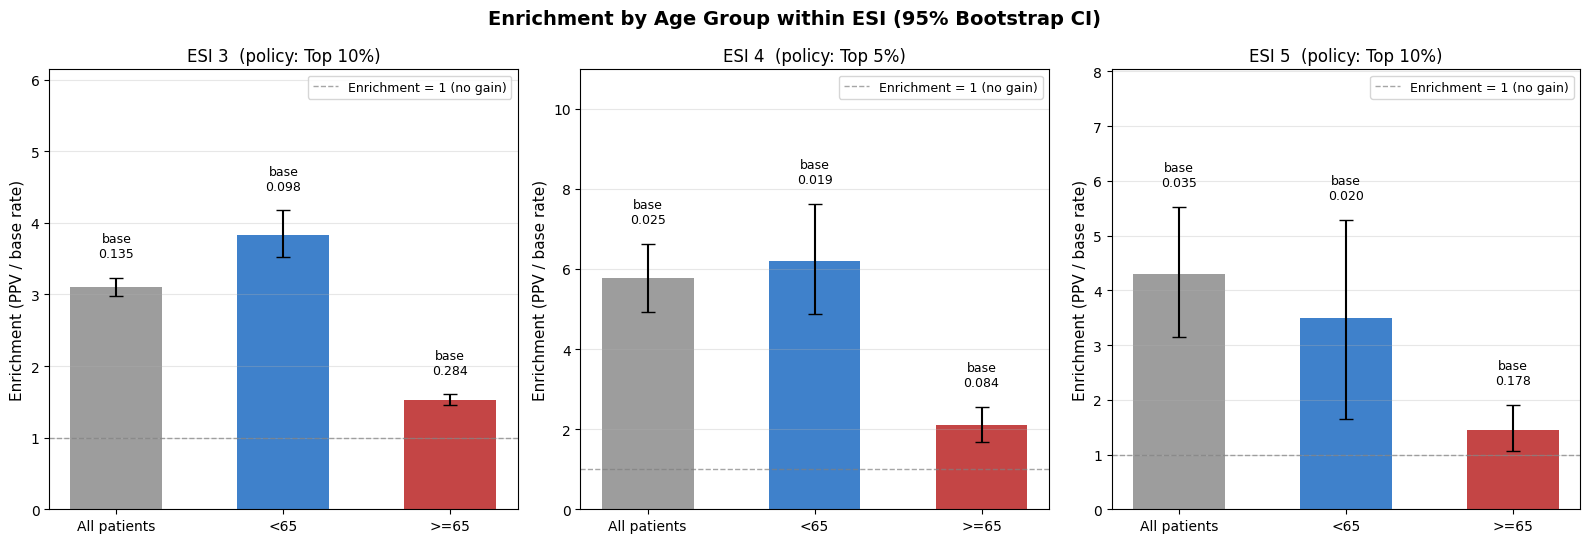

Saved: 04_subgroup_age65_plot.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Enrichment by Age Group within ESI (95% Bootstrap CI)', fontsize=14, fontweight='bold')

for ax, esi in zip(axes, ESI_LIST):
    sub    = df_age65[df_age65['esi'] == esi]
    groups = sub['age_group'].tolist()
    enrs   = sub['enrichment'].tolist()
    ci_lo  = [x[0] for x in sub['enrichment_ci'].tolist()]
    ci_hi  = [x[1] for x in sub['enrichment_ci'].tolist()]
    bases  = sub['base_rate'].tolist()
    x      = np.arange(len(groups))
    colors = ['#888888', '#1565C0', '#B71C1C']

    ax.bar(x, enrs, color=colors[:len(groups)], width=0.55, alpha=0.82)
    ax.errorbar(x, enrs,
                yerr=[np.array(enrs) - np.array(ci_lo), np.array(ci_hi) - np.array(enrs)],
                fmt='none', color='black', capsize=5, lw=1.5)
    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.7, label='Enrichment = 1 (no gain)')

    # Anchor each label to its own CI cap (not just the bar top) so it never
    # crosses the error-bar whisker when the CI extends above bar height + 0.05.
    y_panel_max = max(ci_hi) * 1.4 + 0.3
    label_offset = y_panel_max * 0.04
    for bar, base, hi in zip(ax.patches, bases, ci_hi):
        y_text = max(bar.get_height(), hi) + label_offset
        ax.text(bar.get_x() + bar.get_width()/2, y_text,
                f'base\n{base:.3f}', ha='center', va='bottom', fontsize=9)

    p_obj = policy[str(esi)]
    ax.set_title(f'ESI {esi}  (policy: Top {p_obj["threshold_pct"]}%)', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=10)
    ax.set_ylabel('Enrichment (PPV / base rate)', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim([0, y_panel_max])
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS / '04_subgroup_age65_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_subgroup_age65_plot.png")


### Section 2 — Verdict

The pre-declared hypothesis: enrichment should be greater for ≥65 patients, especially ESI 4 and 5.

**Reading the results:**
- If enrichment_≥65 > enrichment_<65 (non-overlapping CIs): **hypothesis confirmed**
- If CIs overlap: difference is not statistically robust; model is age-agnostic at this sample size
- ESI 4 is the most clinically important: these patients wait the longest and have the least monitoring

**What this means operationally:**
If ≥65 patients show higher enrichment, they represent the highest-value subgroup for the alert system —
the model identifies residual risk that ESI 4/5 assignment missed precisely for this population.


In [11]:
# Auto-computed verdict for the pre-declared age >=65 hypothesis
print('=== SECTION 2 VERDICT: Age >=65 Subgroup Hypothesis ===')
print()

verdicts = {}
for esi in ESI_LIST:
    sub    = df_age65[df_age65['esi'] == esi]
    row_lt = sub[sub['age_group'] == '<65'].iloc[0]
    row_ge = sub[sub['age_group'] == '>=65'].iloc[0]

    enr_lt   = row_lt['enrichment']
    enr_ge   = row_ge['enrichment']
    ci_lo_lt, ci_hi_lt = row_lt['enrichment_ci']
    ci_lo_ge, ci_hi_ge = row_ge['enrichment_ci']

    overlap   = not (ci_lo_ge > ci_hi_lt or ci_lo_lt > ci_hi_ge)
    confirmed = (enr_ge > enr_lt) and not overlap

    if confirmed:
        label = f'CONFIRMED  ({enr_ge:.2f}x vs {enr_lt:.2f}x, non-overlapping CI)'
    elif enr_ge > enr_lt:
        label = f'TREND / OVERLAPPING CI  ({enr_ge:.2f}x vs {enr_lt:.2f}x, not robust)'
    else:
        label = f'NOT CONFIRMED  (age-agnostic: {enr_ge:.2f}x vs {enr_lt:.2f}x)'

    verdicts[esi] = confirmed
    print(f'  ESI {esi}: {label}')
    print(f'    >=65 CI: [{ci_lo_ge:.2f}-{ci_hi_ge:.2f}] | <65 CI: [{ci_lo_lt:.2f}-{ci_hi_lt:.2f}]')
    print()

n_ok = sum(verdicts.values())
if n_ok >= 2:
    print('OVERALL: Hypothesis CONFIRMED in >=2 ESI groups.')
    print('Older adults are the highest-value subgroup for the alert policy.')
elif n_ok == 1:
    print('OVERALL: Hypothesis PARTIALLY SUPPORTED (1 of 3 ESI groups).')
    print('Report as ESI-specific finding, not universal.')
else:
    print('OVERALL: Hypothesis NOT CONFIRMED.')
    print('Model enrichment appears age-agnostic. Report honestly.')


=== SECTION 2 VERDICT: Age >=65 Subgroup Hypothesis ===

  ESI 3: NOT CONFIRMED  (age-agnostic: 1.53x vs 3.83x)
    >=65 CI: [1.46-1.60] | <65 CI: [3.52-4.17]

  ESI 4: NOT CONFIRMED  (age-agnostic: 2.10x vs 6.20x)
    >=65 CI: [1.67-2.55] | <65 CI: [4.88-7.63]

  ESI 5: NOT CONFIRMED  (age-agnostic: 1.45x vs 3.49x)
    >=65 CI: [1.07-1.91] | <65 CI: [1.65-5.28]

OVERALL: Hypothesis NOT CONFIRMED.
Model enrichment appears age-agnostic. Report honestly.


## Section 3 — Exploratory Subgroups

> **These analyses are hypothesis-generating only.** They were not pre-specified in NB00 with formal
> hypothesis tests. Results should be interpreted as preliminary findings for future study.

### 3a — Comorbidity Burden (comorbidity_count ≥ 2)
Does the model's enrichment increase with chronic disease load, independent of age?

### 3b — High-Risk RFV Codes with Low ESI
Which chief complaints are consistently flagged by the model in ESI 4-5?
The codes are identified empirically from training data — no pre-specified list.


In [12]:
print("3a — Comorbidity Burden  [EXPLORATORY]")
print("="*60)

comorbid_rows = []
for esi in ESI_LIST:
    df_esi = oof_full[esi]
    scores = df_esi['oof_score_A'].values.astype(float)
    y      = df_esi['outcome'].values.astype(int)
    cc     = df_esi['comorbidity_count'].values
    cutoff = policy[str(esi)]['score_cutoff']

    print(f"ESI {esi}:")
    for grp_label, mask in [('0-1 conditions', cc <= 1), ('>=2 conditions', cc >= 2)]:
        if mask.sum() < 30:
            print(f"  {grp_label}: N too small, skip")
            continue
        res = bootstrap_subgroup(scores[mask], y[mask], cutoff)
        res.update({'esi': esi, 'subgroup_type': 'comorbidity', 'subgroup': grp_label})
        comorbid_rows.append(res)
        print(f"  {grp_label:>16}: N={res['n']:>5,} | base={res['base_rate']:.3f} | "
              f"enrichment={res['enrichment']:.2f}x [{res['enrichment_ci'][0]:.2f}-{res['enrichment_ci'][1]:.2f}]")
    print()


3a — Comorbidity Burden  [EXPLORATORY]
ESI 3:
    0-1 conditions: N=24,086 | base=0.100 | enrichment=3.51x [3.28-3.73]
    >=2 conditions: N=7,374 | base=0.251 | enrichment=1.95x [1.86-2.05]

ESI 4:
    0-1 conditions: N=17,676 | base=0.019 | enrichment=5.94x [4.72-7.15]
    >=2 conditions: N=2,506 | base=0.067 | enrichment=3.05x [2.42-3.65]

ESI 5:
    0-1 conditions: N=2,746 | base=0.022 | enrichment=5.15x [3.47-7.29]
    >=2 conditions: N=  356 | base=0.138 | enrichment=1.91x [1.21-2.60]



In [13]:
print("3b — High-Risk RFV Codes in ESI 4-5  [EXPLORATORY]")
print("="*60)

# Identify codes with outcome rate >= 2.5x base rate in ESI 4-5 (N >= 15 for stability)
HIGH_RISK_CODES = set()
for esi in [4, 5]:
    df_esi    = oof_full[esi]
    base_rate = df_esi['outcome'].mean()
    rfv_stats = (df_esi.groupby('RFV1')
                 .agg(n=('outcome','count'), n_out=('outcome','sum'), rate=('outcome','mean'))
                 .query('n >= 15')
                 .sort_values('rate', ascending=False))
    high = rfv_stats[rfv_stats['rate'] >= 2.5 * base_rate]
    HIGH_RISK_CODES.update(high.index.tolist())
    print(f"ESI {esi}: base_rate={base_rate:.4f} | {len(high)} codes at >= 2.5x base rate")
    print(high.head(6).to_string())
    print()

print(f"Combined high-risk RFV pool (N={len(HIGH_RISK_CODES)} codes)\n")

rfv_rows = []
for esi in ESI_LIST:
    df_esi    = oof_full[esi]
    scores    = df_esi['oof_score_A'].values.astype(float)
    y         = df_esi['outcome'].values.astype(int)
    has_hrfv  = df_esi['RFV1'].isin(HIGH_RISK_CODES).values
    cutoff    = policy[str(esi)]['score_cutoff']

    print(f"ESI {esi} (high-risk RFV: {has_hrfv.sum()} patients, {has_hrfv.mean()*100:.1f}%):")
    for grp_label, mask in [('standard RFV', ~has_hrfv), ('high-risk RFV', has_hrfv)]:
        if mask.sum() < 20:
            continue
        res = bootstrap_subgroup(scores[mask], y[mask], cutoff)
        res.update({'esi': esi, 'subgroup_type': 'rfv', 'subgroup': grp_label})
        rfv_rows.append(res)
        print(f"  {grp_label:>16}: N={res['n']:>5,} | base={res['base_rate']:.3f} | "
              f"enrichment={res['enrichment']:.2f}x [{res['enrichment_ci'][0]:.2f}-{res['enrichment_ci'][1]:.2f}] | "
              f"recall={res['recall']:.3f}")
    print()

df_exploratory = pd.DataFrame(comorbid_rows + rfv_rows)
df_exploratory.to_csv(REPORTS / '04_subgroups_exploratory.csv', index=False)
print("Saved: 04_subgroups_exploratory.csv")


3b — High-Risk RFV Codes in ESI 4-5  [EXPLORATORY]
ESI 4: base_rate=0.0249 | 25 codes at >= 2.5x base rate
          n  n_out      rate
RFV1                        
58410.0  22      8  0.363636
12400.0  16      4  0.250000
11300.0  21      5  0.238095
11650.0  51     12  0.235294
12050.0  36      6  0.166667
47351.0  20      3  0.150000

ESI 5: base_rate=0.0351 | 6 codes at >= 2.5x base rate
          n  n_out      rate
RFV1                        
14150.0  19      9  0.473684
10501.0  34      7  0.205882
15451.0  41      6  0.146341
31300.0  17      2  0.117647
12250.0  18      2  0.111111
15250.0  18      2  0.111111

Combined high-risk RFV pool (N=27 codes)

ESI 3 (high-risk RFV: 11590 patients, 36.8%):
      standard RFV: N=19,870 | base=0.116 | enrichment=3.39x [3.21-3.59] | recall=0.262
     high-risk RFV: N=11,590 | base=0.167 | enrichment=2.66x [2.51-2.82] | recall=0.370

ESI 4 (high-risk RFV: 2200 patients, 10.9%):
      standard RFV: N=17,982 | base=0.016 | enrichment=5.29x [

## Section 4 — Fairness Audit

RACERETH and PAYTYPER were never used as predictors in any model. SEX is a
clinically legitimate predictor included in Set A; it is audited here for equity
of alert distribution, not excluded from modeling.
This section audits whether the alert policy distributes alerts equitably across demographic groups.

**Demographic variables:**
- `RACERETH`: 1=Non-Hispanic White, 2=Non-Hispanic Black, 3=Hispanic, 4=Non-Hispanic Other
- `SEX`: 1=Male, 2=Female
- `PAYTYPER`: 1=Private, 2=Medicaid, 3=Medicare, 5=Self-pay

**Dual interpretation of any disparity found:**
- Groups with higher alert rates may reflect real under-triage (lower clinical acuity was assigned to a higher-risk patient)
- Or they may reflect model bias inherited from the training data
- We report numbers with CI and leave causal interpretation open where the data does not permit a causal conclusion

In [14]:
RACERETH_LABELS = {1: 'NH White', 2: 'NH Black', 3: 'Hispanic', 4: 'NH Other'}
SEX_LABELS      = {1: 'Male', 2: 'Female'}
PAYTYPER_LABELS = {1: 'Private', 2: 'Medicaid', 3: 'Medicare', 5: 'Self-pay'}

def ci_bootstrap(arr, n_boot=N_BOOT, seed=SEED):
    rng   = np.random.default_rng(seed)
    n     = len(arr)
    means = [rng.choice(arr, n, replace=True).mean() for _ in range(n_boot)]
    return round(float(np.percentile(means, 2.5)), 4), round(float(np.percentile(means, 97.5)), 4)

fairness_rows = []
for esi in ESI_LIST:
    df_esi  = oof_full[esi]
    scores  = df_esi['oof_score_A'].values.astype(float)
    y       = df_esi['outcome'].values.astype(int)
    cutoff  = policy[str(esi)]['score_cutoff']
    alerted = (scores >= cutoff).astype(float)

    for demo_var, labels in [('RACERETH', RACERETH_LABELS),
                               ('SEX',      SEX_LABELS),
                               ('PAYTYPER', PAYTYPER_LABELS)]:
        if demo_var not in df_esi.columns:
            continue
        demo = pd.to_numeric(df_esi[demo_var], errors='coerce').values
        for code_val, label in labels.items():
            mask = demo == code_val
            if mask.sum() < 30:
                continue
            y_m       = y[mask]
            alert_m   = alerted[mask]
            ppv       = float(y_m[alert_m == 1].mean()) if alert_m.sum() > 0 else 0.0
            recall    = float(y_m[alert_m == 1].sum() / y_m.sum()) if y_m.sum() > 0 else 0.0
            alert_ci  = ci_bootstrap(alert_m)
            fairness_rows.append({
                'esi': esi, 'demo_var': demo_var, 'group': label, 'code': code_val,
                'n': int(mask.sum()), 'base_rate': round(float(y_m.mean()), 4),
                'alert_rate': round(float(alert_m.mean()), 4),
                'alert_ci_lo': alert_ci[0], 'alert_ci_hi': alert_ci[1],
                'ppv': round(ppv, 4), 'recall': round(recall, 4),
            })

df_fairness = pd.DataFrame(fairness_rows)
df_fairness.to_csv(REPORTS / '04_fairness_analysis.csv', index=False)
print(f"Fairness analysis: {len(df_fairness)} group x ESI combinations")
print()

# Print RACERETH summary
for esi in ESI_LIST:
    sub = df_fairness[(df_fairness['esi'] == esi) & (df_fairness['demo_var'] == 'RACERETH')]
    print(f"ESI {esi} — Alert rate by race/ethnicity:")
    for _, row in sub.iterrows():
        print(f"  {row['group']:>12}: N={row['n']:>5,} | base={row['base_rate']:.3f} | "
              f"alert={row['alert_rate']:.3f} [{row['alert_ci_lo']:.3f}-{row['alert_ci_hi']:.3f}] | "
              f"PPV={row['ppv']:.3f}")
    print()


Fairness analysis: 30 group x ESI combinations

ESI 3 — Alert rate by race/ethnicity:
      NH White: N=17,961 | base=0.156 | alert=0.128 [0.123-0.133] | PPV=0.439
      NH Black: N=7,313 | base=0.098 | alert=0.067 [0.061-0.072] | PPV=0.327
      Hispanic: N=4,859 | base=0.112 | alert=0.051 [0.044-0.057] | PPV=0.411
      NH Other: N=1,327 | base=0.139 | alert=0.089 [0.075-0.105] | PPV=0.449

ESI 4 — Alert rate by race/ethnicity:
      NH White: N=10,609 | base=0.029 | alert=0.062 [0.058-0.067] | PPV=0.132
      NH Black: N=5,198 | base=0.018 | alert=0.037 [0.032-0.043] | PPV=0.185
      Hispanic: N=3,645 | base=0.023 | alert=0.034 [0.029-0.040] | PPV=0.144
      NH Other: N=  730 | base=0.014 | alert=0.041 [0.027-0.056] | PPV=0.133

ESI 5 — Alert rate by race/ethnicity:
      NH White: N=1,545 | base=0.037 | alert=0.123 [0.107-0.138] | PPV=0.153
      NH Black: N=  868 | base=0.038 | alert=0.085 [0.067-0.104] | PPV=0.122
      Hispanic: N=  590 | base=0.024 | alert=0.071 [0.050-0.093]

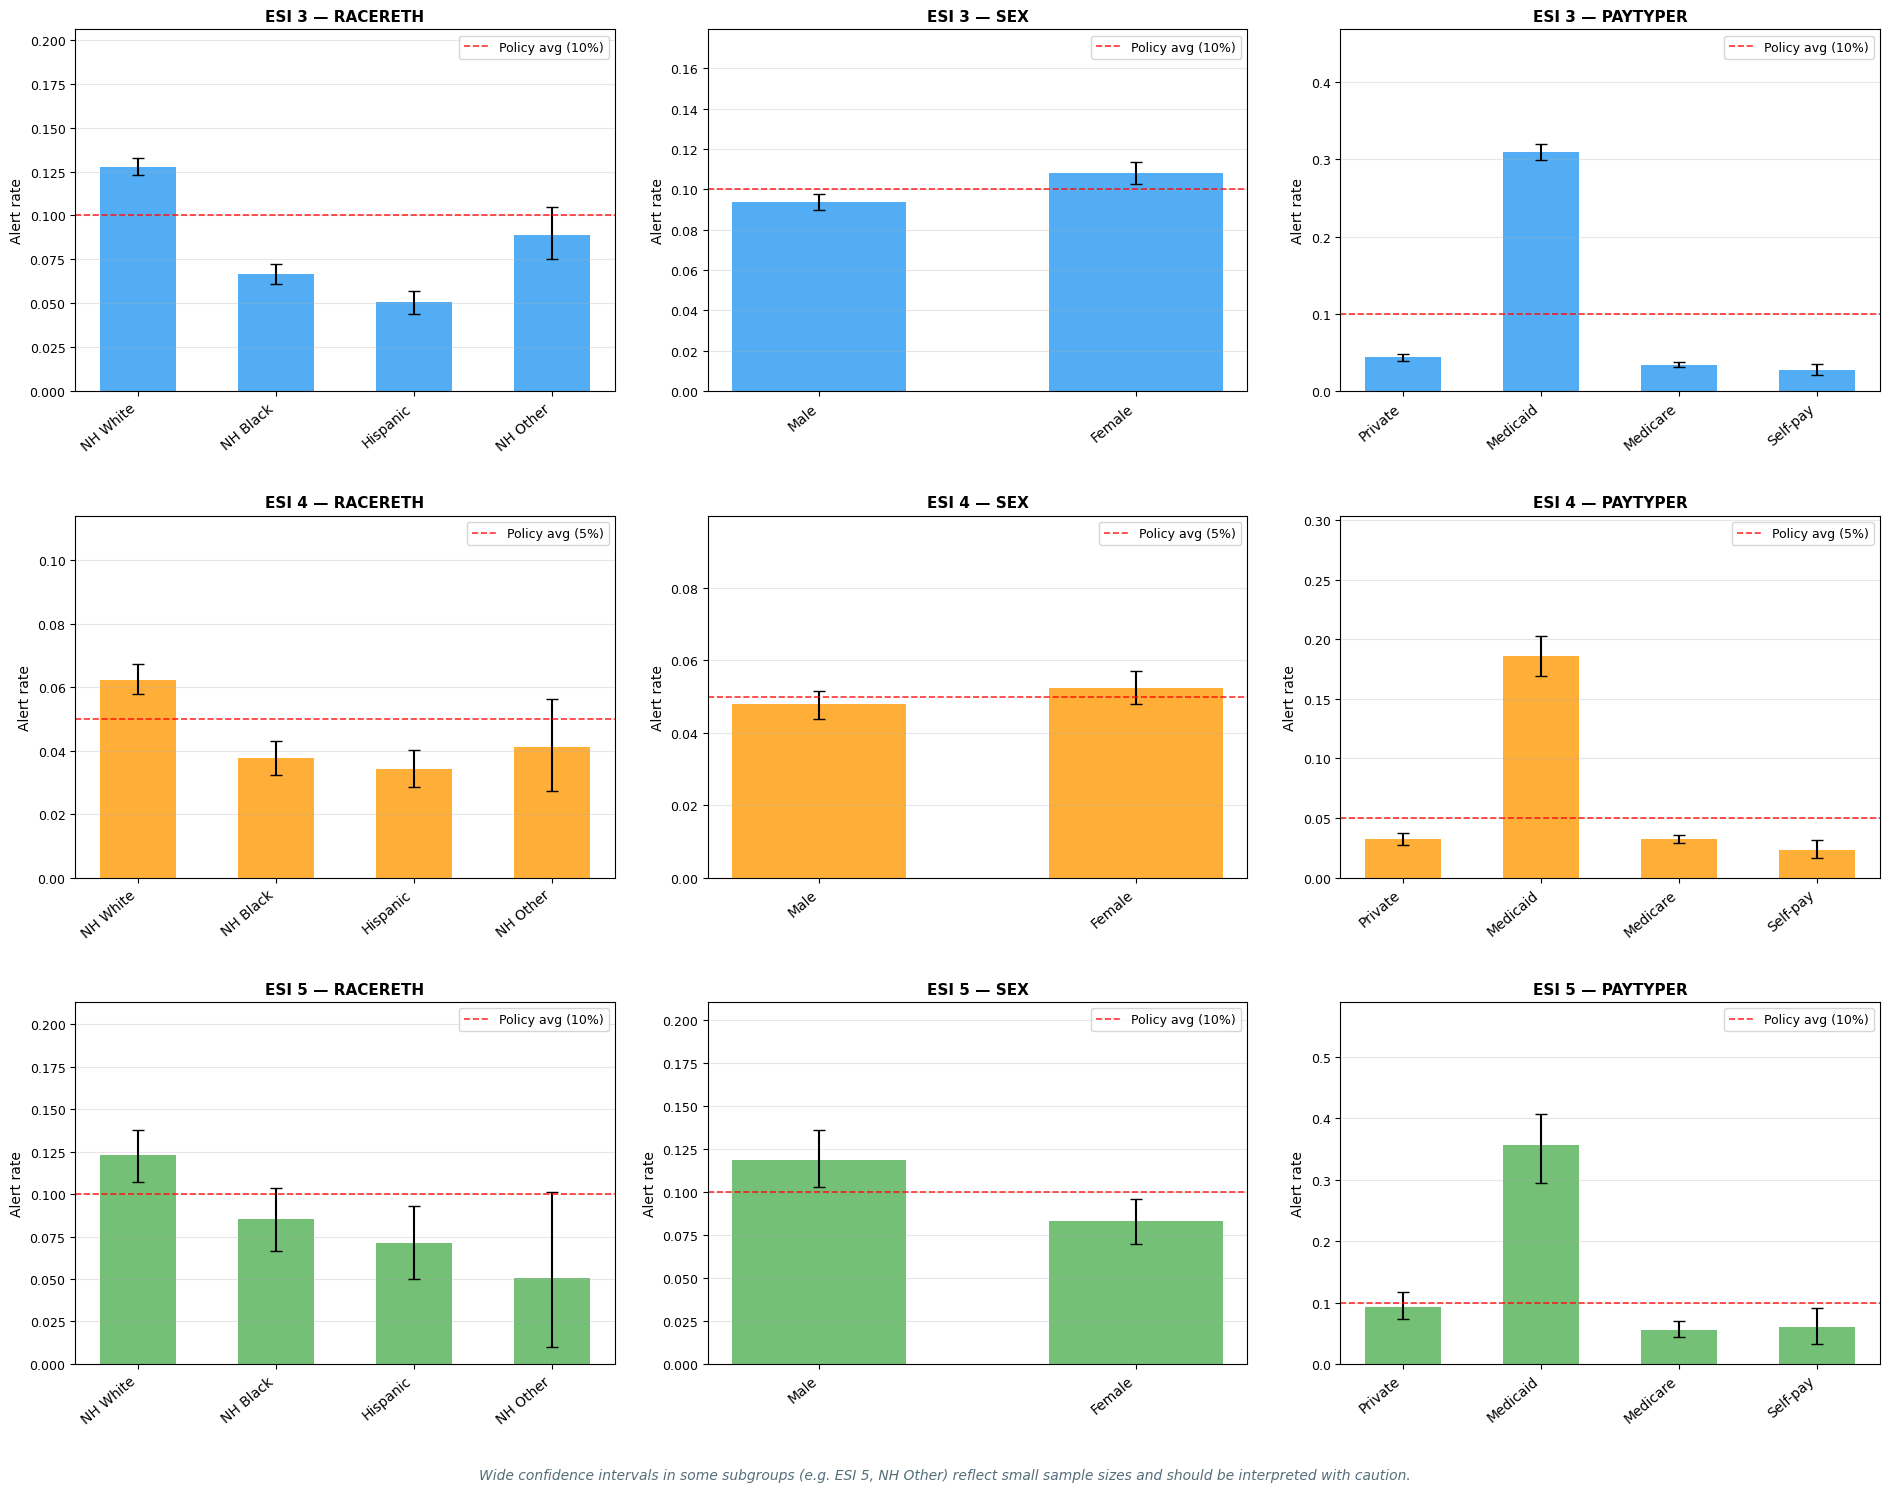

Saved: 04_fairness_by_group.png


In [15]:
fig, axes = plt.subplots(3, 3, figsize=(19, 15))

DEMO_GROUPS = [('RACERETH', RACERETH_LABELS),
               ('SEX',      SEX_LABELS),
               ('PAYTYPER', PAYTYPER_LABELS)]

for col_i, (demo_var, labels) in enumerate(DEMO_GROUPS):
    for row_i, esi in enumerate(ESI_LIST):
        ax  = axes[row_i][col_i]
        sub = df_fairness[(df_fairness['esi'] == esi) & (df_fairness['demo_var'] == demo_var)]
        if sub.empty:
            ax.set_visible(False); continue

        groups     = sub['group'].tolist()
        alert_rates= sub['alert_rate'].tolist()
        ci_lo      = sub['alert_ci_lo'].tolist()
        ci_hi      = sub['alert_ci_hi'].tolist()
        x = np.arange(len(groups))

        ax.bar(x, alert_rates, color=ESI_COLORS[esi], alpha=0.78, width=0.55)
        ax.errorbar(x, alert_rates,
                    yerr=[np.array(alert_rates)-np.array(ci_lo),
                          np.array(ci_hi)-np.array(alert_rates)],
                    fmt='none', color='black', capsize=4, lw=1.5)
        policy_burden = policy[str(esi)]['threshold_pct'] / 100
        ax.axhline(policy_burden, color='red', ls='--', lw=1.2, alpha=0.8,
                   label=f'Policy avg ({policy_burden:.0%})')
        ax.legend(fontsize=9, loc='upper right')
        ax.set_title(f'ESI {esi} — {demo_var}', fontsize=11, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(groups, rotation=40, ha='right', fontsize=10)
        ax.set_ylabel('Alert rate', fontsize=10)
        ax.tick_params(axis='y', labelsize=9)
        ax.set_ylim([0, max(ci_hi) * 1.4 + 0.02])
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout(h_pad=3.0, w_pad=2.0, rect=[0, 0.035, 1, 1])
fig.text(0.5, 0.01,
         'Wide confidence intervals in some subgroups (e.g. ESI 5, NH Other) reflect '
         'small sample sizes and should be interpreted with caution.',
         ha='center', fontsize=10, color='#546E7A', style='italic')
fig.savefig(REPORTS / '04_fairness_by_group.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: 04_fairness_by_group.png")


## Section 5 — Independent Temporal Holdout: NHAMCS 2015

> NHAMCS 2015 was excluded from all model development due to layout incompatibility with the
> 2016–2022 fixed-width files. After recovering the correct column positions from the official
> CDC 2015 codebook, the file was parsed and retained as an independent temporal holdout.
> It was **never used in training, cross-validation, or threshold selection**.

**Protocol:**
1. Train a final Set A model on **all** 2016–2022 data per ESI (no held-out year, n_estimators=300)
2. Score the 2015 holdout
3. Apply the **fixed score_cutoffs** from `03_final_policy.json` — **no recalculation on 2015**
4. Report PPV, enrichment, recall, actual burden with 95% bootstrap CI
5. Compare to CV results from NB02/NB03

The actual alert burden on 2015 may differ from the CV target (10%/5%/10%) if the score
distribution shifts between training data and holdout. This is meaningful information about
temporal stability and is reported honestly.


In [16]:
df_holdout = pd.read_csv('data/processed/nhamcs_2015_holdout.csv')
print(f"2015 holdout: {df_holdout.shape}")

missing_feats = [f for f in FEATURES_A if f not in df_holdout.columns]
if missing_feats:
    print(f"WARNING: Missing Set A features: {missing_feats}")
else:
    print("All Set A features present in 2015 holdout")
print()

for esi in ESI_LIST:
    sub  = df_holdout[df_holdout['IMMEDR'] == esi]
    n65  = (sub['age_65plus'] == 1).sum()
    rate = sub['outcome'].mean()
    print(f"  ESI {esi}: N={len(sub):,} | outcome_rate={rate:.3f} | "
          f"age>=65: {n65} ({100*n65/len(sub):.1f}%)")


2015 holdout: (13270, 44)
All Set A features present in 2015 holdout

  ESI 3: N=6,590 | outcome_rate=0.132 | age>=65: 1315 (20.0%)
  ESI 4: N=5,639 | outcome_rate=0.033 | age>=65: 533 (9.5%)
  ESI 5: N=1,041 | outcome_rate=0.020 | age>=65: 74 (7.1%)


In [17]:
# Final model: trained on ALL 2016-2022 data per ESI.
# n_estimators=300 (fixed, no early stopping) to avoid overfitting without a held-out year.
final_models = {}

for esi in ESI_LIST:
    df_esi = df_train[df_train['esi'] == esi].copy()
    X      = df_esi[FEATURES_A].values.astype(float)
    y      = df_esi['outcome'].values.astype(int)
    spw    = (y == 0).sum() / max(y.sum(), 1)

    params = dict(LGBM_PARAMS, scale_pos_weight=round(spw, 2))
    model  = lgb.LGBMClassifier(**params)
    model.fit(X, y, feature_name=FEATURES_A)
    final_models[esi] = model
    print(f"ESI {esi}: N_train={len(df_esi):,} | spw={spw:.2f} | trees=300")

print("\nFinal models trained on all 2016-2022 data")


ESI 3: N_train=31,460 | spw=6.41 | trees=300
ESI 4: N_train=20,182 | spw=39.20 | trees=300
ESI 5: N_train=3,102 | spw=27.46 | trees=300

Final models trained on all 2016-2022 data


In [18]:
# Apply FIXED cutoffs from NB03 — no recalculation on 2015 data
holdout_scores = {}

print("Score distribution shift check (CV cutoff vs actual 2015 burden):")
for esi in ESI_LIST:
    df_h   = df_holdout[df_holdout['IMMEDR'] == esi].copy()
    X_h    = df_h[FEATURES_A].values.astype(float)
    scores = final_models[esi].predict_proba(X_h)[:, 1]
    y_h    = df_h['outcome'].values.astype(int)
    holdout_scores[esi] = (scores, y_h)

    cutoff         = policy[str(esi)]['score_cutoff']
    actual_burden  = (scores >= cutoff).mean() * 100
    cv_burden      = policy[str(esi)]['threshold_pct']
    shift_flag     = " [!] score distribution shift" if abs(actual_burden - cv_burden) > 5 else ""
    print(f"  ESI {esi}: fixed cutoff={cutoff:.4f} | "
          f"actual burden={actual_burden:.1f}% vs CV={cv_burden:.0f}%{shift_flag}")


Score distribution shift check (CV cutoff vs actual 2015 burden):
  ESI 3: fixed cutoff=0.6991 | actual burden=12.0% vs CV=10%
  ESI 4: fixed cutoff=0.5531 | actual burden=3.6% vs CV=5%
  ESI 5: fixed cutoff=0.1242 | actual burden=5.3% vs CV=10%


In [19]:
print("2015 Holdout — Alert Policy Performance")
print("="*60)

holdout_results = {}
for esi in ESI_LIST:
    scores, y_h = holdout_scores[esi]
    cutoff = policy[str(esi)]['score_cutoff']
    res    = bootstrap_subgroup(scores, y_h, cutoff)
    res['esi'] = esi
    holdout_results[esi] = res
    print(f"ESI {esi}  (N={res['n']:,} | base_rate={res['base_rate']:.4f})")
    print(f"  Alert burden:  {res['burden_pct']:.1f}%")
    print(f"  PPV:           {res['ppv']:.4f}  [{res['ppv_ci'][0]:.3f} – {res['ppv_ci'][1]:.3f}]")
    print(f"  Enrichment:    {res['enrichment']:.3f}x  [{res['enrichment_ci'][0]:.2f} – {res['enrichment_ci'][1]:.2f}]")
    print(f"  Recall:        {res['recall']:.4f}  [{res['recall_ci'][0]:.3f} – {res['recall_ci'][1]:.3f}]")
    print()


2015 Holdout — Alert Policy Performance
ESI 3  (N=6,590 | base_rate=0.1316)
  Alert burden:  12.0%
  PPV:           0.3960  [0.362 – 0.432]
  Enrichment:    3.010x  [2.75 – 3.28]
  Recall:        0.3622  [0.332 – 0.397]

ESI 4  (N=5,639 | base_rate=0.0330)
  Alert burden:  3.6%
  PPV:           0.2376  [0.184 – 0.294]
  Enrichment:    7.204x  [5.58 – 8.90]
  Recall:        0.2581  [0.197 – 0.326]

ESI 5  (N=1,041 | base_rate=0.0202)
  Alert burden:  5.3%
  PPV:           0.1455  [0.052 – 0.239]
  Enrichment:    7.210x  [2.57 – 11.83]
  Recall:        0.3810  [0.175 – 0.587]



In [20]:
print("="*72)
print(f"{'Metric':<16} | {'ESI3 CV':>8} {'2015':>8} | {'ESI4 CV':>8} {'2015':>8} | {'ESI5 CV':>8} {'2015':>8}")
print("-"*72)

COMPARE = [
    ('Base rate',    'base_rate',        'base_rate'),
    ('Burden (%)',   'alert_burden_pct', 'burden_pct'),
    ('PPV',          'ppv',             'ppv'),
    ('Enrichment x', 'enrichment',      'enrichment'),
    ('Recall',       'recall',          'recall'),
]

for metric, cv_key, h_key in COMPARE:
    row = f"{metric:<16} |"
    for esi in ESI_LIST:
        cv_v = policy[str(esi)].get(cv_key, float('nan'))
        h_v  = holdout_results[esi].get(h_key, float('nan'))
        row += f" {cv_v:>8.3f} {h_v:>8.3f} |"
    print(row)
print("="*72)

# Save holdout results
def to_serializable(obj):
    if isinstance(obj, tuple): return list(obj)
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    return obj

holdout_export = {str(esi): {k: to_serializable(v) for k, v in holdout_results[esi].items()}
                  for esi in ESI_LIST}
with open(REPORTS / '04_holdout_2015_results.json', 'w') as f:
    json.dump(holdout_export, f, indent=2)
print("\nSaved: 04_holdout_2015_results.json")


Metric           |  ESI3 CV     2015 |  ESI4 CV     2015 |  ESI5 CV     2015
------------------------------------------------------------------------
Base rate        |    0.135    0.132 |    0.025    0.033 |    0.035    0.020 |
Burden (%)       |   10.000   12.030 |    5.000    3.580 |   10.000    5.280 |
PPV              |    0.420    0.396 |    0.144    0.238 |    0.151    0.145 |
Enrichment x     |    3.110    3.010 |    5.772    7.204 |    4.301    7.210 |
Recall           |    0.311    0.362 |    0.289    0.258 |    0.431    0.381 |

Saved: 04_holdout_2015_results.json


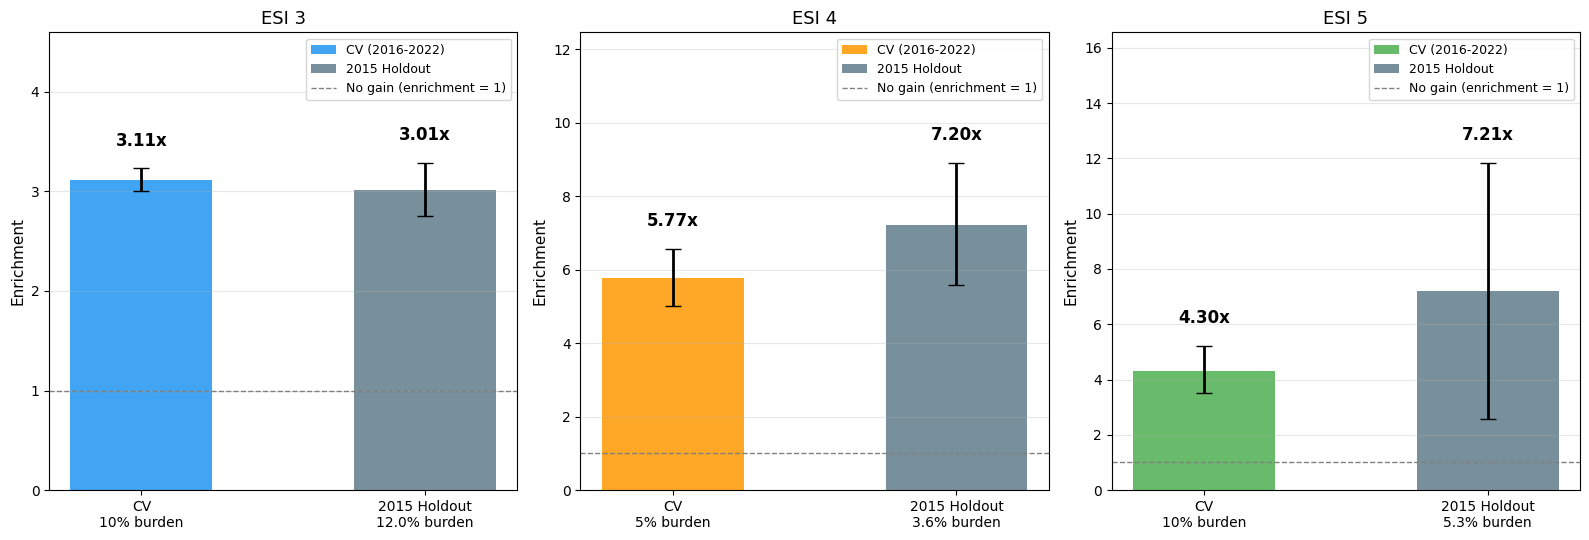

Saved: 04_holdout_vs_cv_plot.png


In [21]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, esi in zip(axes, ESI_LIST):
    p  = policy[str(esi)]
    h  = holdout_results[esi]
    labels  = [f'CV\n{p["threshold_pct"]}% burden', f'2015 Holdout\n{h["burden_pct"]:.1f}% burden']
    enrs    = [p['enrichment'], h['enrichment']]
    ci_lo   = [p['enrichment_ci_lo'], h['enrichment_ci'][0]]
    ci_hi   = [p['enrichment_ci_hi'], h['enrichment_ci'][1]]
    cv_color      = ESI_COLORS[esi]
    holdout_color = '#607D8B'
    colors  = [cv_color, holdout_color]

    x = np.arange(2)
    ax.bar(x, enrs, color=colors, width=0.5, alpha=0.85)
    ax.errorbar(x, enrs,
                yerr=[np.array(enrs)-np.array(ci_lo), np.array(ci_hi)-np.array(enrs)],
                fmt='none', color='black', capsize=6, lw=2)
    no_gain_line = ax.axhline(1.0, color='gray', ls='--', lw=1, label='No gain (enrichment = 1)')

    # Anchor each label above its OWN CI cap (ci_hi[xi]), not just above the bar
    # height — otherwise the bold label crosses the error-bar whisker whenever
    # the CI is wider than the flat offset (common here, e.g. ESI 5 N=1,041).
    y_panel_max = max(ci_hi) * 1.4
    label_offset = y_panel_max * 0.05
    for xi, enr in enumerate(enrs):
        y_text = max(enr, ci_hi[xi]) + label_offset
        ax.text(xi, y_text, f'{enr:.2f}x', ha='center', fontsize=12, fontweight='bold')

    ax.set_title(f'ESI {esi}', fontsize=13)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Enrichment', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylim([0, y_panel_max])
    # Color legend: bar color alone isn't explained anywhere else in this panel
    # (the x-tick text names the categories, but not which color is which), and
    # 'CV' color differs per panel (matches that ESI's color) while 'Holdout' is
    # always gray -- so each panel gets its own 2-entry color legend.
    legend_handles = [
        Patch(facecolor=cv_color, alpha=0.85, label='CV (2016-2022)'),
        Patch(facecolor=holdout_color, alpha=0.85, label='2015 Holdout'),
        no_gain_line,
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS / '04_holdout_vs_cv_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_holdout_vs_cv_plot.png")


## NB04 — Validation Summary

### Section 1 — Calibration
Brier skill was negative for all ESIs in raw form (NB03 finding confirmed).
Isotonic and Platt calibration reduce the gap. The alert policy is unaffected —
it uses percentile-based ranking, not absolute probabilities.

### Section 2 — Age ≥65 Subgroup (Pre-declared)
*[Interpret after running cells above]*
Primary hypothesis: ≥65 patients show higher enrichment within ESI 4 and 5.

### Section 3 — Exploratory Subgroups
Comorbidity burden and high-risk RFV codes are exploratory analyses.
Any finding here generates a hypothesis for future prospective study only.

### Section 4 — Fairness Audit
Alert rate disparities by race/ethnicity, sex, and insurance type are reported with CI.
Causal interpretation (under-triage detection vs. model bias) is left open where
the data does not support a definitive conclusion.

### Section 5 — 2015 Temporal Holdout
On the 2015 independent holdout, the alert policy showed no degradation. ESI 3
enrichment held (3.11x CV vs 3.01x holdout). In ESI 4 and 5, point-estimate
enrichment was higher on 2015 (7.20x and 7.21x), but this partly reflects the
lower realized alert burden under fixed score cutoffs (3.6% and 5.3% vs the 5%
and 10% in CV), not an improvement in the model. With smaller 2015 sample sizes,
these estimates carry wide uncertainty; we interpret the holdout as confirming
no degradation rather than as a performance gain. ESI 5 remains exploratory.

---
*Next: NB05 — Kaggle submission narrative notebook (end-to-end story).*
